# Data Exploration
The first thing I did with this dataset.
Justify data cleaning filters, unit guessing, etc.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from IPython.display import display

In [2]:
# load company A data
df_a = pd.read_csv('data/company_a_1.csv')
df_a = pd.concat([df_a, pd.read_csv('data/company_a_2.csv')])
df_a = pd.concat([df_a, pd.read_csv('data/company_a_3.csv')])
df_a = pd.concat([df_a, pd.read_csv('data/company_a_4.csv')])
df_a = pd.concat([df_a, pd.read_csv('data/company_a_5.csv')])

# load company B data
df_b = pd.read_csv('data/company_b_1.csv')
df_b = pd.concat([df_b, pd.read_csv('data/company_b_2.csv')])

In [3]:
# Check the columns and data format
print(len(df_a), len(df_b), df_a.isnull().sum().sum(), df_b.isnull().sum().sum())
display(df_a.head(3))
display(df_b.head(3))

57365 10578 2 0


,TripID,ScooterID,StartTime,EndTime,StartLatitude,StartLongitude,EndLatitude,EndLongitude,TripDistance
0,0e56a534-66f4-448b-8eaa-beab76509955,5bc901d7-b714-4c57-a614-3d7193da825a,8/9/18 10:24,8/9/18 10:26,38.25,-85.76,38.25,-85.76,0.04
1,d9280fb0-8135-4750-9c71-c610789ba005,3d1905ec-85be-4773-9fe2-34421073363f,8/9/18 10:26,8/9/18 10:56,38.25,-85.74,38.26,-85.77,1.98
2,48fa27f3-3b19-4f0e-8665-ee0b188445fd,5bc901d7-b714-4c57-a614-3d7193da825a,8/9/18 10:26,8/9/18 10:35,38.25,-85.76,38.25,-85.76,0.06


,trip_id,start_time,completed_time,distance_meters,start_latitude,start_longitude,end_latitude,end_longitude
0,26559444,2018-12-02T12:41:26.000+00:00,2018-12-02T12:45:40.000+00:00,382,38.23,-85.75,38.23,-85.76
1,26559031,2018-12-02T12:39:24.000+00:00,2018-12-02T12:41:49.000+00:00,109,38.26,-85.75,38.26,-85.76
2,26552748,2018-12-02T12:08:07.000+00:00,2018-12-02T12:18:29.000+00:00,2547,38.21,-85.75,38.23,-85.75


A company has a scooter ID, while B is not. We have more information of A and we want to compare something with B company.
- Company A data has two missing values. We may check it later.
- Not only NULL values, but also there can be other types of invalid values. 

We don't know what's the unit of distance of company A. This is a variable in our analysis, so let's find out first.

In [4]:
#Let's join two dataframes for convenience

# Match column names with B
df_a.rename(columns={
    'TripID': 'trip_id',
    'ScooterID': 'scooter_id', 
    'StartTime': 'start_time',
    'EndTime': 'end_time',
    'StartLongitude': 'start_longitude', 
    'StartLatitude': 'start_latitude', 
    'EndLongitude': 'end_longitude', 
    'EndLatitude': 'end_latitude',
    'TripDistance': 'distance_m', # We don't know the unit yet
    }, inplace=True)


def get_distance_meters (lat,long,lat2,long2,earth_radius_meters = 6371000):
    '''
    Calculate the distance between two points in miles
    Input: latitude, longitude, latitude2, longitude2 (assumes they are in degrees)
    '''
    del_degree = ((lat2 - lat)**2 + (long2 - long)**2)**0.5
    del_radian = del_degree*math.pi/180
    distance_meters  = earth_radius_meters*del_radian
    return distance_meters


df_a['distance_compare_m'] = get_distance_meters(df_a.start_latitude, df_a.start_longitude, df_a.end_latitude, df_a.end_longitude)

print('resolution of distance_compare_m', get_distance_meters(0.01,0.01,0,0))

df_a.head(12)


resolution of distance_compare_m 1572.5337332781642


,trip_id,scooter_id,start_time,end_time,start_latitude,start_longitude,end_latitude,end_longitude,distance_m,distance_compare_m
0,0e56a534-66f4-448b-8eaa-beab76509955,5bc901d7-b714-4c57-a614-3d7193da825a,8/9/18 10:24,8/9/18 10:26,38.25,-85.76,38.25,-85.76,0.04,0.000000
1,d9280fb0-8135-4750-9c71-c610789ba005,3d1905ec-85be-4773-9fe2-34421073363f,8/9/18 10:26,8/9/18 10:56,38.25,-85.74,38.26,-85.77,1.98,3516.292325
2,48fa27f3-3b19-4f0e-8665-ee0b188445fd,5bc901d7-b714-4c57-a614-3d7193da825a,8/9/18 10:26,8/9/18 10:35,38.25,-85.76,38.25,-85.76,0.06,0.000000
3,6321b580-9055-4418-8c17-1d39a4d49027,4d49088f-4038-4dfb-9d55-e58a157d56d5,8/9/18 10:37,8/9/18 10:56,38.25,-85.74,38.26,-85.77,1.85,3516.292325
4,d05bf0bb-f6ee-489e-a32c-a93e15b626f8,e398ff1b-5d6b-4f15-b493-a988c7ab07b6,8/9/18 10:41,8/9/18 10:47,38.26,-85.75,38.26,-85.76,0.35,1111.949266
5,43e4d861-d8e0-4c90-9c54-dcf05073c9e0,cc1df8d9-2b1d-4bdd-b0c7-46a3c147b0c5,8/9/18 10:41,8/9/18 10:45,38.26,-85.75,38.26,-85.75,0.26,0.000000
6,9f1a20e8-0340-450d-b5c8-76e2ef1b89f4,560c78fc-cce7-45fb-8e84-9056e2350196,8/9/18 10:41,8/9/18 10:43,38.25,-85.76,38.25,-85.76,0.02,0.000000
7,0d5d6b31-f3d0-483b-bfea-cce538fdd2eb,90ad2ac5-3cfa-4fa9-a4cf-faa4d5087485,8/9/18 10:42,8/9/18 13:35,38.25,-85.76,38.25,-85.76,8.96,0.000000
8,58128c5f-6df0-4539-92e4-4d0fbd992046,2dd803cd-adf7-4ecc-9d33-af77dd5c8275,8/9/18 10:49,8/9/18 10:55,38.26,-85.76,38.26,-85.76,0.13,0.000000
9,8f247849-3976-46ec-b696-8ef9766f9783,b71d66fb-bd2d-409b-9a47-1dde8c846608,8/9/18 10:51,8/9/18 10:57,38.26,-85.76,38.25,-85.76,0.73,1111.949266


Note that the resolusion of the distance reconstructed by lat/long coordinate is a mile. 

In [5]:
# Guess unit
print(3516.292325/1.98, 3516.292325/1.85, 1111.949266/0.35, 1111.949266/0.73, 2223.898533/1.37)


1775.9052146464646 1900.6985540540538 3176.9979028571433 1523.21817260274 1623.283600729927


They are close to miles to meters conversion or its double (round trip in this case I guess).
Convert miles to meters and see if data looks reasonable.

(array([5.7358e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00, 5.0000e+00]),
 array([-1.66476728e+07,  1.99763829e+08,  4.16175330e+08,  6.32586832e+08,
         8.48998334e+08,  1.06540984e+09,  1.28182134e+09,  1.49823284e+09,
         1.71464434e+09,  1.93105584e+09,  2.14746734e+09]),
 <BarContainer object of 10 artists>)

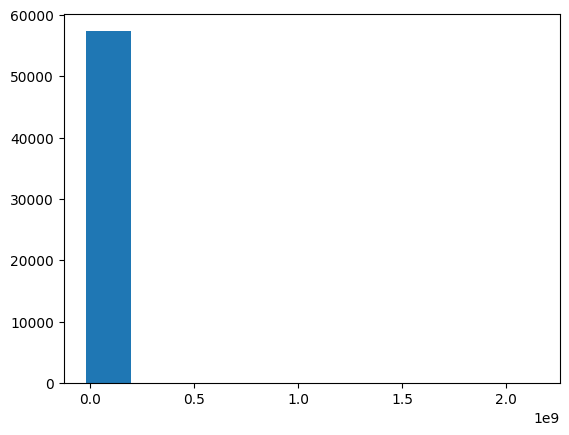

In [6]:
# Convers miles to meters
df_a.distance_m = df_a.distance_m*1609.34

plt.hist(df_a.distance_m)

Some values are incorrect. Let's take a look.

In [7]:
# Check outliers
df_a[df_a.distance_m>1e5]

,trip_id,scooter_id,start_time,end_time,start_latitude,start_longitude,end_latitude,end_longitude,distance_m,distance_compare_m
1195,d29102fa-094d-47bc-9aff-468e1a3ef8ae,55179511-3d9f-4def-b9e2-24af25712217,10/1/18 18:32,10/1/18 18:44,38.26,-85.73,38.25,-85.73,1.789158e+09,1111.949266
1495,5cc29f4d-b809-456d-b1ad-bdd4f58a6b30,55afb762-f8e9-4fba-ab2a-9969493e9959,10/2/18 14:43,10/2/18 15:04,38.24,-85.76,38.24,-85.76,2.147399e+09,0.000000
1698,37eea201-67bc-4d9d-b1d7-fc4ec002e137,9b555b61-1aca-414b-89e2-2dba4ec7b4d1,10/2/18 18:23,10/2/18 18:43,38.22,-85.69,38.24,-85.69,2.147467e+09,2223.898533
5950,8fc8a42a-95d1-41e5-8497-be90a2acfb2b,83cc60dd-2323-4e12-97c6-73010a061bf9,10/9/18 20:16,10/9/18 20:40,38.24,-85.72,38.23,-85.72,1.952978e+09,1111.949266
11398,3bd10575-4a19-4af3-b7f4-58382f95bf52,a24e5657-6892-4842-92f0-c053b27dc659,10/20/18 13:30,10/20/18 14:25,38.24,-85.72,38.26,-85.76,2.147389e+09,4972.788295
12029,fa9225a2-7331-47a6-a173-445187c02a1c,bf9a5882-49f9-46f6-aca0-94474e0a3041,10/21/18 11:25,10/21/18 12:00,38.25,-85.74,38.25,-85.75,1.323852e+09,1111.949266
159,81cbcbdb-471b-45c5-be8e-77d769a77d6c,317b92b3-d5e3-40f9-b601-30f3a88b78c7,11/2/18 7:56,11/2/18 7:57,38.23,-85.71,38.23,-85.71,3.167406e+06,0.000000
1476,017c5a12-bce4-4bb1-8499-4e80e55f61e8,4bc1f554-1bde-4596-b3b2-6f22a90528c8,11/6/18 4:51,11/6/18 6:28,38.26,-85.75,38.26,-85.75,2.136510e+09,0.000000
8297,5b8b2a48-a934-4d16-9cf9-5a0f11ddce18,ce7ced9d-9ac4-4823-9144-ec3a89f78b26,11/19/18 19:31,11/19/18 19:34,38.26,-85.75,38.26,-85.75,1.669644e+07,0.000000


Those "distance_meters" values doesn't make sense. A human cannot ride a scooter that much at one trip. We could impute them with distance_compare, but for now, let's drop them as it is just a few.

In [8]:
df_a = df_a[df_a.distance_m<1e5]

(array([1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 5.7354e+04]),
 array([-16647672.7894 , -14973128.76996, -13298584.75052, -11624040.73108,
         -9949496.71164,  -8274952.6922 ,  -6600408.67276,  -4925864.65332,
         -3251320.63388,  -1576776.61444,     97767.405  ]),
 <BarContainer object of 10 artists>)

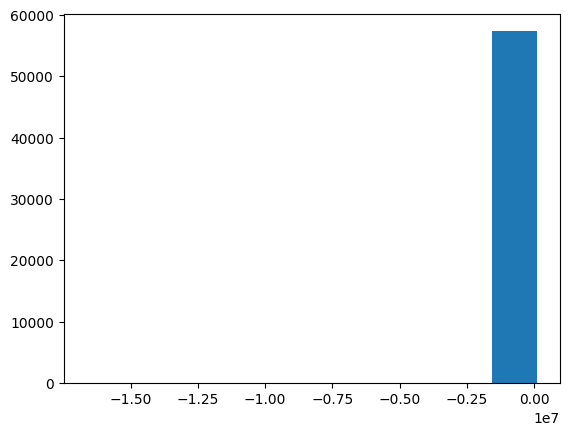

In [9]:
plt.hist(df_a.distance_m)

In [10]:
# Check outliers at <=0
df_a[df_a.distance_m<=0]

,trip_id,scooter_id,start_time,end_time,start_latitude,start_longitude,end_latitude,end_longitude,distance_m,distance_compare_m
34,d42c2f7c-c232-4e0f-b495-1e9962ceff12,2246419c-9386-4886-bf58-5bfd773d81a4,8/9/18 11:42,8/9/18 11:44,38.25,-85.76,38.25,-85.76,0.0,0.0
116,cde2a56e-56df-44bd-b52f-df50469c2e2a,7613980d-842b-4895-a3ac-2680acb9bebe,8/9/18 13:59,8/9/18 14:00,38.24,-85.72,38.24,-85.72,0.0,0.0
524,17b89b06-d519-4f1b-b549-1429e663b543,e36c96a1-8f71-4f47-96cc-b6c9a62e89fa,8/10/18 14:46,8/10/18 14:48,38.25,-85.69,38.25,-85.69,0.0,0.0
821,b62b8383-90cc-44f0-976a-729d27f16721,286a5134-e0c9-4f09-b918-659b63e2b253,8/11/18 12:14,8/11/18 12:15,38.25,-85.74,38.25,-85.74,0.0,0.0
917,35c7ffe0-83f1-4c67-bc8d-946e56e7941e,03584938-7da7-4c13-80db-8b682084e170,8/11/18 15:16,8/11/18 15:19,38.26,-85.76,38.26,-85.76,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
8946,10d75a60-c266-4867-ba42-617bab5212c0,15aca3d0-1f15-4e76-b10b-42451a3a14e4,12/31/18 18:32,12/31/18 18:46,38.25,-85.76,38.25,-85.76,0.0,0.0
8949,1ac91344-1ac0-4c11-a121-5e2f445d0f54,15aca3d0-1f15-4e76-b10b-42451a3a14e4,12/31/18 18:48,12/31/18 18:48,38.25,-85.76,38.25,-85.76,0.0,0.0
8954,4e13f721-7088-4bf1-abca-e30daad88975,e6e76247-bb14-4b8f-846e-e2d8a34d0e47,12/31/18 19:22,12/31/18 19:24,38.23,-85.76,38.23,-85.76,0.0,0.0
8956,2151f357-4854-4a42-a92a-98bd314f7089,8ff0800a-a99e-4db3-99ff-e4fb01506b09,12/31/18 19:31,12/31/18 19:33,38.23,-85.71,38.23,-85.71,0.0,0.0


Most of them are 1-2 seconds run without any movement. We can keep them. Let's check events at <0, if there are.

In [11]:
df_a[df_a.distance_m<0]

,trip_id,scooter_id,start_time,end_time,start_latitude,start_longitude,end_latitude,end_longitude,distance_m,distance_compare_m
9824,4355eaea-cdb4-43ea-a11e-d877ce6cb5c6,72b3541c-8eec-45d2-a606-56620c2dce5c,9/23/18 15:04,9/23/18 16:37,38.24,-85.72,38.25,-85.74,-2.156516e+03,2486.394147
9968,f819ea72-5267-4230-b7fc-02773710513a,98b82db4-e333-4bc4-892e-c8de7436759b,9/23/18 19:49,9/23/18 20:23,38.22,-85.69,38.20,-85.73,-1.090972e+05,4972.788295
11157,5a7539fb-95c5-4561-8090-823c4e8b68b5,2c10fc96-4186-47c6-b403-454717205757,9/28/18 13:36,9/28/18 13:58,38.24,-85.72,38.25,-85.74,-2.599084e+04,2486.394147
11649,0d53a006-7aea-4a9f-b3de-5eb3beaf3588,4bc7bd76-9b9d-4788-9250-130c9e0c15d0,9/29/18 12:52,9/29/18 13:02,38.26,-85.76,38.26,-85.75,-1.931208e+02,1111.949266
11661,b6ccde84-ef9d-4297-a145-5dd62b8910ad,69898951-b04b-41f8-8a3c-e2a12fbaeace,9/29/18 12:59,9/29/18 13:44,38.26,-85.76,38.26,-85.75,-3.057746e+02,1111.949266
...,...,...,...,...,...,...,...,...,...,...
4822,187402a5-2ef5-4189-9322-d5c076e2b479,1286edf3-2d81-4ede-bfba-f65bde6a41bd,12/13/18 20:39,12/13/18 21:01,38.26,-85.75,38.25,-85.74,-2.050299e+04,1572.533733
6366,4e186090-62db-45a8-a8fc-6ae23fdf8ff7,230bb1f7-7d09-478a-b750-87adffd89f1c,12/19/18 14:33,12/19/18 14:58,38.24,-85.73,38.26,-85.75,-4.869863e+04,3145.067467
6520,cfbab9c6-858e-4a96-919f-4cbb1f9e4ec8,112c9279-a289-4bdf-a172-f769c8b5c1b7,12/19/18 19:22,12/19/18 20:23,38.26,-85.76,38.25,-85.76,-3.260523e+04,1111.949266
6772,6393de57-c309-4db9-9747-045771081bc0,a249c424-7e46-4fd3-bda0-55621ce9752c,12/21/18 14:10,12/21/18 14:14,38.25,-85.76,38.25,-85.76,-6.448110e+06,0.000000


We don't know why there can be minus distances. Let's drop them, too.

In [12]:
df_a = df_a[df_a.distance_m>=0]

print(len(df_a),len(df_a[df_a.distance_compare_m<=0]))

# We want to keep df_a.distance_compare==0. They are probabiliy round trips.

#df_a[(df_a.distance_compare_m>1e5)|(df_a.distance_m>1e4)]



57288 26796


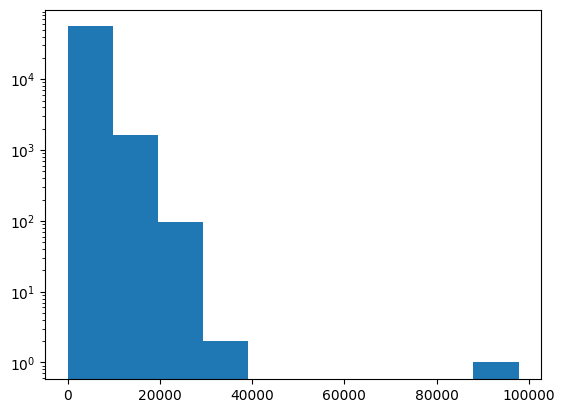

In [13]:
# Now, let's check distribution again
plt.hist(df_a.distance_m)
plt.yscale('log')
plt.show()

Someone ran 100 km, but that may happen. Let's keep it for now.

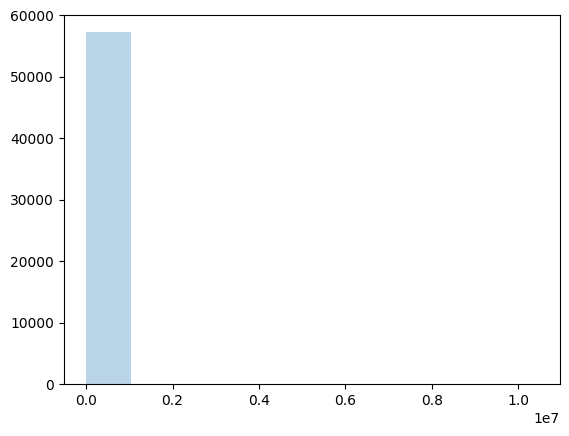

In [14]:
plt.hist(df_a.distance_compare_m, alpha=0.3)
plt.show()

Still weired runs. Further investigation after treating time data.

Now, let's move on time data.

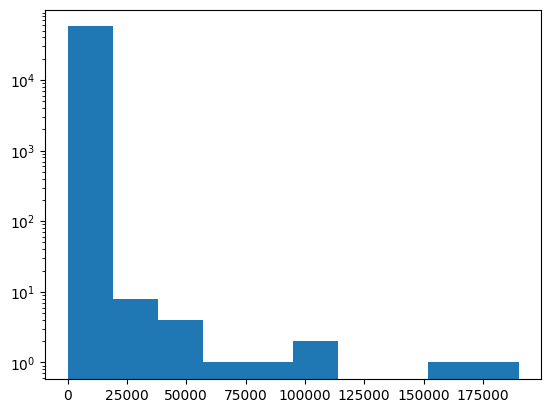

In [15]:

df_a.start_time = pd.to_datetime(df_a.start_time, format='%m/%d/%y %H:%M')
df_a.end_time = pd.to_datetime(df_a.end_time, format='%m/%d/%y %H:%M')
df_a['duration_s'] = (df_a.end_time-df_a.start_time).dt.total_seconds()

plt.hist(df_a['duration_s'])
plt.yscale('log')
plt.show()

Maximum values are more than 1 day... maybe someone rent it for multiple days?

In [16]:
# Now, take a look at B
df_b.rename(columns={'distance_meters': 'distance_m', 'completed_time': 'end_time'}, inplace=True)
df_b.start_time = pd.to_datetime(df_b.start_time)
df_b.end_time = pd.to_datetime(df_b.end_time)
df_b['duration_s'] = (df_b.end_time-df_b.start_time).dt.total_seconds()

# check outliers
df_b[(df_b.distance_m<0)&(df_b.distance_m>1e5)]

,trip_id,start_time,end_time,distance_m,start_latitude,start_longitude,end_latitude,end_longitude,duration_s


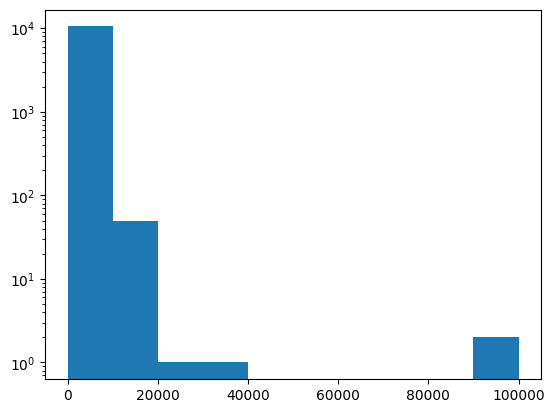

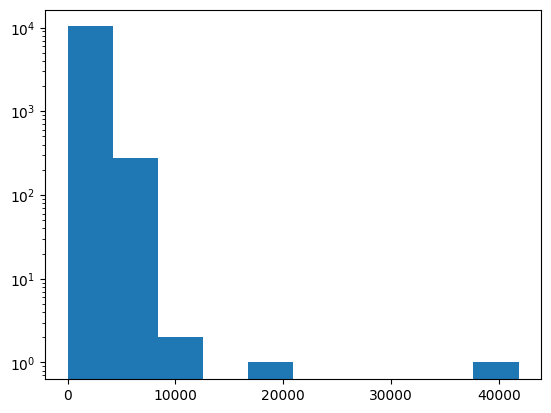

In [17]:
# Check distribution
plt.hist(df_b.distance_m)
plt.yscale('log')
plt.show()

plt.hist(df_b.duration_s)
plt.yscale('log')
plt.show()

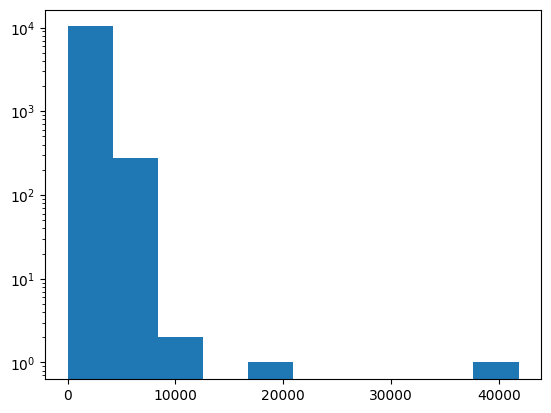

In [18]:
plt.hist(df_b.duration_s)
plt.yscale('log')
plt.show()

In [19]:
df_a

,trip_id,scooter_id,start_time,end_time,start_latitude,start_longitude,end_latitude,end_longitude,distance_m,distance_compare_m,duration_s
0,0e56a534-66f4-448b-8eaa-beab76509955,5bc901d7-b714-4c57-a614-3d7193da825a,2018-08-09 10:24:00,2018-08-09 10:26:00,38.25,-85.76,38.25,-85.76,64.3736,0.000000,120.0
1,d9280fb0-8135-4750-9c71-c610789ba005,3d1905ec-85be-4773-9fe2-34421073363f,2018-08-09 10:26:00,2018-08-09 10:56:00,38.25,-85.74,38.26,-85.77,3186.4932,3516.292325,1800.0
2,48fa27f3-3b19-4f0e-8665-ee0b188445fd,5bc901d7-b714-4c57-a614-3d7193da825a,2018-08-09 10:26:00,2018-08-09 10:35:00,38.25,-85.76,38.25,-85.76,96.5604,0.000000,540.0
3,6321b580-9055-4418-8c17-1d39a4d49027,4d49088f-4038-4dfb-9d55-e58a157d56d5,2018-08-09 10:37:00,2018-08-09 10:56:00,38.25,-85.74,38.26,-85.77,2977.2790,3516.292325,1140.0
4,d05bf0bb-f6ee-489e-a32c-a93e15b626f8,e398ff1b-5d6b-4f15-b493-a988c7ab07b6,2018-08-09 10:41:00,2018-08-09 10:47:00,38.26,-85.75,38.26,-85.76,563.2690,1111.949266,360.0
...,...,...,...,...,...,...,...,...,...,...,...
8976,36ce0228-e16b-4c1f-abfd-b647703021f2,7ebaece5-550b-4d5f-97e6-c7be3a0970ce,2018-12-31 20:43:00,2018-12-31 21:43:00,38.23,-85.71,38.24,-85.72,305.7746,1572.533733,3600.0
8977,c52348ba-a5af-4d86-a9ac-bb8dc8e68c86,8ff0800a-a99e-4db3-99ff-e4fb01506b09,2018-12-31 20:48:00,2018-12-31 20:59:00,38.23,-85.71,38.23,-85.71,1013.8842,0.000000,660.0
8978,6b91ef5d-d609-4eda-870d-80b6f8edf73b,50eb545b-9357-4830-809e-a63a058b19e9,2018-12-31 20:50:00,2018-12-31 20:57:00,38.25,-85.74,38.25,-85.76,1335.7522,2223.898533,420.0
8979,ede0673d-9e03-4205-bcc3-3be9a8d39f6a,dfa1518e-77be-4847-97cc-3dbc5348ee26,2018-12-31 20:51:00,2018-12-31 21:00:00,38.22,-85.75,38.22,-85.75,627.6426,0.000000,540.0


In [20]:
df_a['company'] = 'A'
df_b['company'] = 'B'

# Before matching the time, let's convert time zone of company B. 
# From one of it's coordinates, 38.25° N, 85.70° W, it is Louisville, following EDT

# Their times have different format. Let's match them before join.
df_a['week'] = df_a.start_time.dt.to_period('W').dt.start_time
df_b['week'] = df_b.start_time.dt.tz_convert('US/Eastern').dt.to_period('W').dt.start_time

df_a['date'] = df_a.start_time.dt.date
df_b['date'] = df_b.start_time.dt.tz_convert('US/Eastern').dt.date

df_a['hour'] = df_a.start_time.dt.hour
df_b['hour'] = df_b.start_time.dt.tz_convert('US/Eastern').dt.hour

df_a['day'] = df_a.start_time.dt.day_name()
df_b['day'] = df_b.start_time.dt.tz_convert('US/Eastern').dt.day_name()


df = pd.concat([df_a, df_b])
display(df.head(3))
display(df.tail(3))



/var/folders/17/90t77pg52r52xjkljh4djjs40000gn/T/ipykernel_9094/3202718217.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_b['week'] = df_b.start_time.dt.tz_convert('US/Eastern').dt.to_period('W').dt.start_time


,trip_id,scooter_id,start_time,end_time,start_latitude,start_longitude,end_latitude,end_longitude,distance_m,distance_compare_m,duration_s,company,week,date,hour,day
0,0e56a534-66f4-448b-8eaa-beab76509955,5bc901d7-b714-4c57-a614-3d7193da825a,2018-08-09 10:24:00,2018-08-09 10:26:00,38.25,-85.76,38.25,-85.76,64.3736,0.000000,120.0,A,2018-08-06,2018-08-09,10,Thursday
1,d9280fb0-8135-4750-9c71-c610789ba005,3d1905ec-85be-4773-9fe2-34421073363f,2018-08-09 10:26:00,2018-08-09 10:56:00,38.25,-85.74,38.26,-85.77,3186.4932,3516.292325,1800.0,A,2018-08-06,2018-08-09,10,Thursday
2,48fa27f3-3b19-4f0e-8665-ee0b188445fd,5bc901d7-b714-4c57-a614-3d7193da825a,2018-08-09 10:26:00,2018-08-09 10:35:00,38.25,-85.76,38.25,-85.76,96.5604,0.000000,540.0,A,2018-08-06,2018-08-09,10,Thursday


,trip_id,scooter_id,start_time,end_time,start_latitude,start_longitude,end_latitude,end_longitude,distance_m,distance_compare_m,duration_s,company,week,date,hour,day
6487,36112862,NaN,2019-01-24 10:43:10+00:00,2019-01-24 10:48:16+00:00,38.24,-85.73,38.24,-85.72,1236.0,NaN,306.0,B,2019-01-21,2019-01-24,5,Thursday
6488,36562276,NaN,2019-01-26 12:48:41+00:00,2019-01-26 13:00:06+00:00,38.25,-85.76,38.26,-85.76,2360.0,NaN,685.0,B,2019-01-21,2019-01-26,7,Saturday
6489,37160463,NaN,2019-01-29 12:59:30+00:00,2019-01-29 13:01:26+00:00,38.22,-85.76,38.22,-85.76,388.0,NaN,116.0,B,2019-01-28,2019-01-29,7,Tuesday


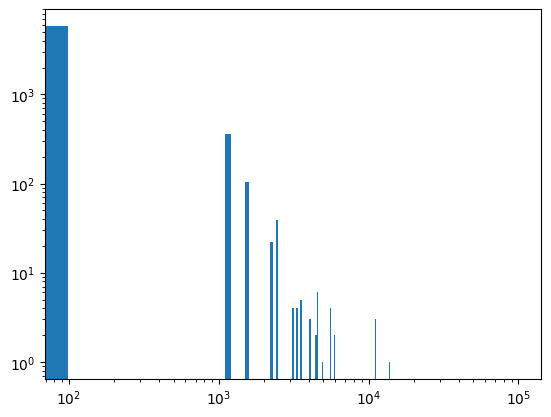

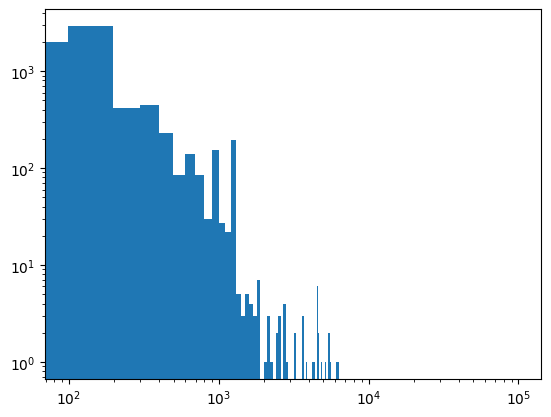

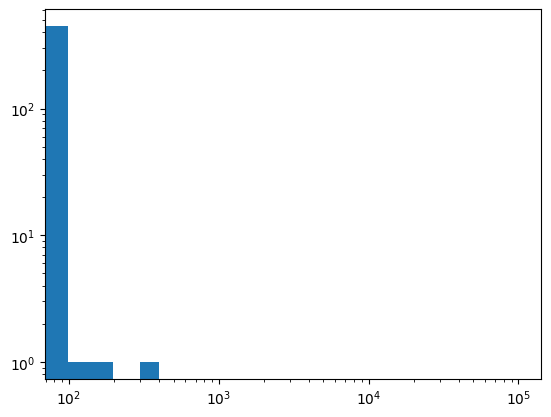

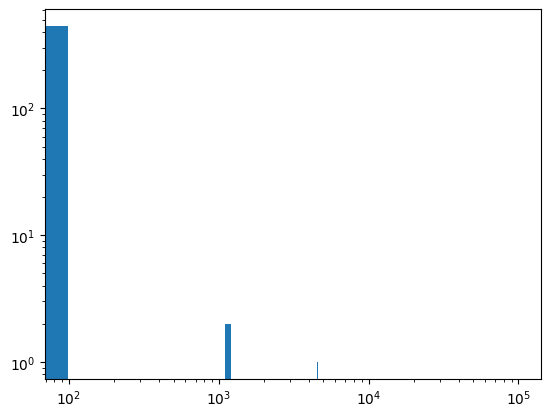

In [21]:
# Decide wether to keep small distance or duration data, which are not likely actual use.
plt.hist(df[df.distance_m<10].distance_compare_m, bins=1000, range=(-2,1e5))
plt.yscale('log')
plt.xscale('log')
plt.show()
plt.hist(df[df.distance_m<5].duration_s, bins=1000, range=(-2,1e5))
plt.yscale('log')
plt.xscale('log')
plt.show()
plt.hist(df[df.duration_s<5].distance_m, bins=1000, range=(-2,1e5))
plt.yscale('log')
plt.xscale('log')
plt.show()
plt.hist(df[df.duration_s<10].distance_compare_m, bins=1000, range=(-2,1e5))
plt.yscale('log')
plt.xscale('log')
plt.show()


They are either incorrect or have no useful information. Let's drop them.

In [22]:
# Drop distance=0 data
df = df[(df.distance_m>5)&(df.duration_s>10)]


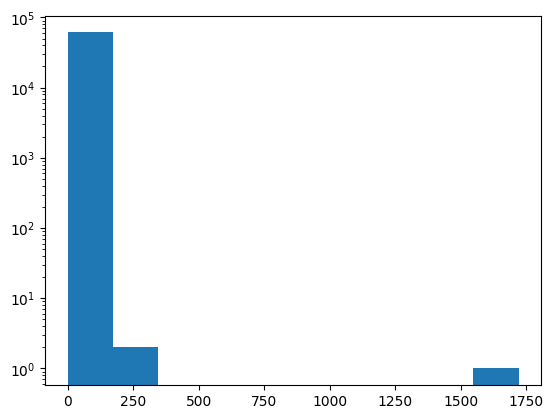

In [23]:
# Get average velocity

df['speed_miles_per_hour'] = (df.distance_m/1609.34)/((df.duration_s)/3600) 
plt.hist(df.speed_miles_per_hour) #, bins=100, range=(0,100))
plt.yscale('log')
plt.show()



Clearly, some data is incorrect. Let's take a look.

In [24]:
df[df.speed_miles_per_hour>100]

,trip_id,scooter_id,start_time,end_time,start_latitude,start_longitude,end_latitude,end_longitude,distance_m,distance_compare_m,duration_s,company,week,date,hour,day,speed_miles_per_hour
11897,46640a9d-6620-42fc-8a8e-c3e9ff907144,1fe846e9-d555-42c9-b55b-4fb1a1d95f62,2018-10-20 18:19:00,2018-10-20 18:20:00,38.26,-85.76,38.26,-85.76,3604.9216,0.000000,60.0,A,2018-10-15,2018-10-20,18,Saturday,134.400000
438,d2651b53-67db-44cc-a354-8d574d0b3613,497c7a56-8fbd-4204-b2bd-bd1128ff1b59,2018-12-02 16:13:00,2018-12-02 16:34:00,38.26,-85.73,38.25,-85.74,97767.4050,1572.533733,1260.0,A,2018-11-26,2018-12-02,16,Sunday,173.571429
1041,30258468,NaN,2018-12-22 10:14:20+00:00,2018-12-22 10:16:50+00:00,38.26,-85.76,38.26,-85.76,16676.0000,NaN,150.0,B,2018-12-17,2018-12-22,5,Saturday,248.688282
1433,30286619,NaN,2018-12-22 12:45:42+00:00,2018-12-22 12:46:49+00:00,38.22,-85.76,38.22,-85.76,3730.0000,NaN,67.0,B,2018-12-17,2018-12-22,7,Saturday,124.534225
527,36404406,NaN,2019-01-25 17:49:23+00:00,2019-01-25 17:51:33+00:00,38.26,-85.75,38.26,-85.75,100000.0000,NaN,130.0,B,2019-01-21,2019-01-25,12,Friday,1720.724501


Those are short runs that seemlingly have error in distance recordings. Let's drop those runs.

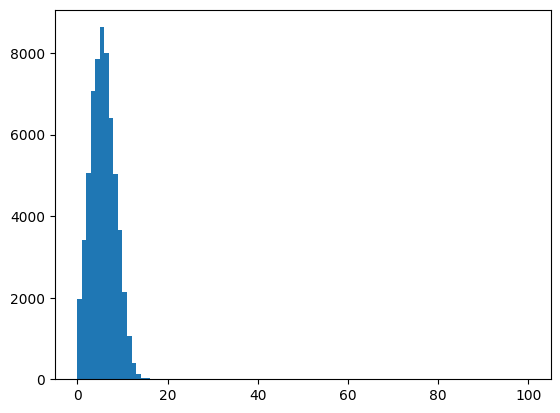

In [25]:
df = df[df.speed_miles_per_hour<100]

plt.hist(df.speed_miles_per_hour, bins=100, range=(0,100))
plt.show()

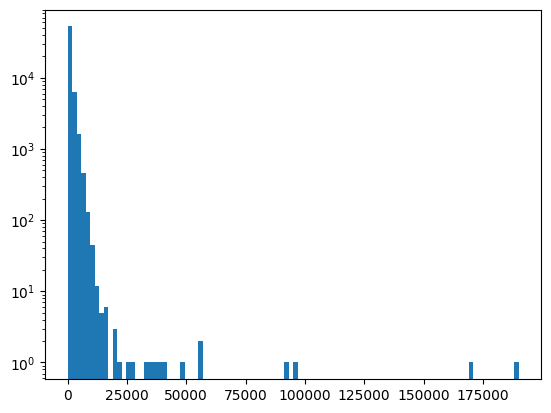

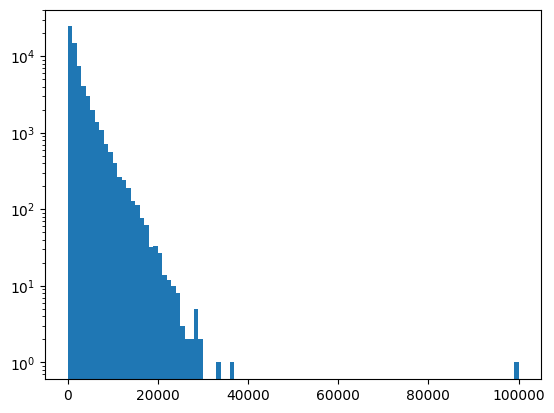

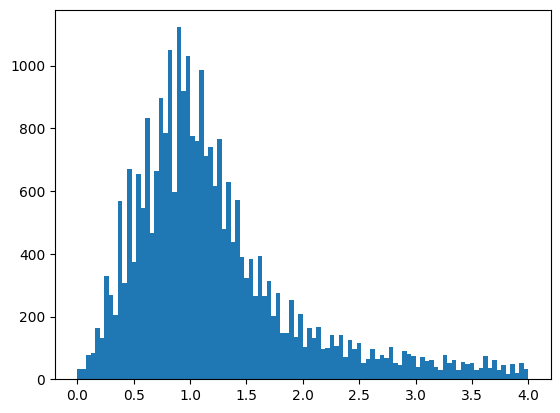

In [26]:
# Now, let's check other features we will use.
plt.hist(df.duration_s, bins=100)
plt.yscale('log')
plt.show()

plt.hist(df.distance_m, bins=100)
plt.yscale('log')
plt.show()

plt.hist(df.distance_m/(df.distance_compare_m+1e-8), bins=100, range=(0,4))
#plt.yscale('log')
plt.show()



Looks ok. The distance unit of the company A seems correct, seeing peak at 1. It can be larger if the moving is not straight. It can be smaller than 1 due to coarse resolution of lat/long coordinate.
Let's move on to analysis then.

Now, move on to business findings

## Findings

### Key Performance Metrics
I suggest
1. Total driven miles per unit time: It estimates the tocal revenue per unit time.
2. Total operation time per unit time per scooter: It estimates the fraction of time where scooters are in use. It tells wether we want to increase/decrease the scooter. We should increase it if it is in high demend while we should decrease it if it is idle most of time to reduce maintenence cost.
3. Number of entries per unit time: It estimates the number of ride per unit time. It estimate the number of users in the market.

Usually daily fluctuation is too large to see trend. We will use a week as the unit time.


## Number of Scooters Estmiation of Company B


### 1. Assuming same "per-scooter" property
Result depends on different "per-scooter" peroperty shared between company A and company B. Let's assume they share same

    A. Number of ride per scooter per unit time (num_ride_per_week_per_scooter)

    B. Operational bandwidth per unit time (driven_hours_per_week) 


Number of ride per unit time will be same for both company A and B.
- The number of ride per unit time tells the market size, so it will be common for A and B. 
- It will overestimate (underestimate) the result if Company B is less (more) popular than company A.

### 2. Regression
Good for finding hidden pattern, but may not be useful more than 1. if there are not many data points

    A. Function (Linear/polynomial) fit
    - If patterns are simple, it works well.
    - It is more generalized "Assuming same "per-scooter" property" analysis.


    B. Deep learning
    - NN models (or any complicated box models) may show good accuracy scores but they are blackbox and may behave totally wrong when input values's scale is changed, so I won't recommend to use it here, especially when correlation seems simple.


### 3. Other approach
- Thought about connecting end lat/long -> next start lat/long to identify a chain of one schooter's operation, but due to coarse resolution of coordinate, it is discarded.

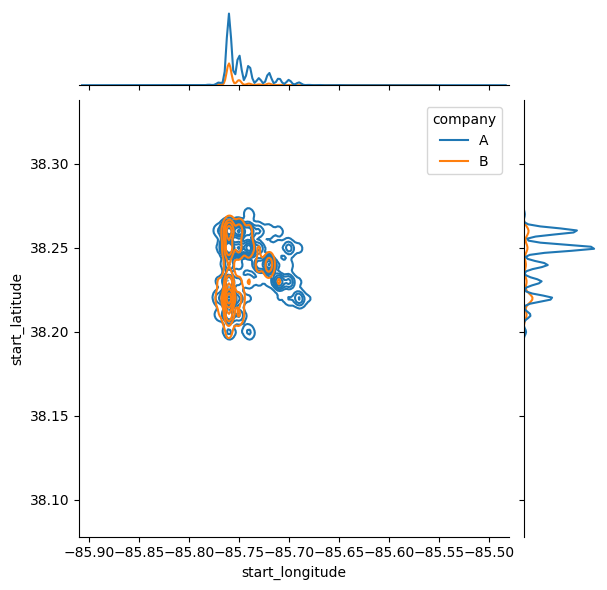

In [27]:
# Coverage comparison
sns.jointplot(df, x = 'start_longitude', y = 'start_latitude', hue = 'company', kind = 'kde')

In [28]:
# Operational characteristics
df[df.company=='A'].distance_m.describe().to_frame().join(df[df.company=='B'].distance_m.describe().to_frame(), how='left', lsuffix='_A', rsuffix='_B')

,distance_m_A,distance_m_B
count,50858.000000,10166.000000
mean,2485.338906,1535.081743
std,2897.512905,1995.671874
min,16.093400,6.000000
25%,692.016200,527.250000
50%,1448.406000,957.000000
75%,3106.026200,1803.500000
max,33603.019200,100000.000000


Compared to company A, company B user travels shorter in average.

In [29]:
# Check operation patterns
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hourly_order = [i for i in range(24)]

df_hour = df.groupby(['hour','company'])[['duration_s', 'distance_m']].sum().reset_index()
df_day = df.groupby(['day','company'])[['duration_s', 'distance_m']].sum().reset_index()
df_day_hour = df.groupby(['day','hour','company'])[['duration_s', 'distance_m']].sum().reset_index()

df_hour['duration_s'] = df_hour['duration_s']/3600
df_hour['distance_m'] = df_hour['distance_m']/1609.34
df_hour.rename(columns={'duration_s': 'operation_hours', 'distance_m': 'driven_miles'}, inplace=True)
df_hour['hour'] = pd.Categorical(df_hour['hour'], categories=hourly_order, ordered=True)
df_hour.sort_values('hour', inplace=True)


df_day['duration_s'] = df_day['duration_s']/3600
df_day['distance_m'] = df_day['distance_m']/1609.34
df_day.rename(columns={'duration_s': 'operation_hours', 'distance_m': 'driven_miles'}, inplace=True)

df_day['day'] = pd.Categorical(df_day['day'], categories=weekday_order, ordered=True)
df_day.sort_values('day', inplace=True)

df_day_hour['duration_s'] = df_day_hour['duration_s']/3600
df_day_hour['distance_m'] = df_day_hour['distance_m']/1609.34
df_day_hour.rename(columns={'duration_s': 'operation_hours', 'distance_m': 'driven_miles'}, inplace=True)

df_day_hour['day'] = pd.Categorical(df_day_hour['day'], categories=weekday_order, ordered=True)
df_day_hour['hour'] = pd.Categorical(df_day_hour['hour'], categories=hourly_order, ordered=True)
df_day_hour.sort_values(['day', 'hour'], inplace=True)
df_day_hour

,day,hour,company,operation_hours,driven_miles
42,Monday,0,B,4.284167,20.306461
43,Monday,1,B,9.356389,36.310537
44,Monday,2,B,8.825000,43.635900
45,Monday,3,B,14.540278,62.242286
46,Monday,4,A,2.916667,15.650000
...,...,...,...,...,...
163,Sunday,20,B,0.680556,0.635664
164,Sunday,21,A,0.883333,3.930000
165,Sunday,21,B,2.680278,9.340475
166,Sunday,22,B,0.527778,3.029192


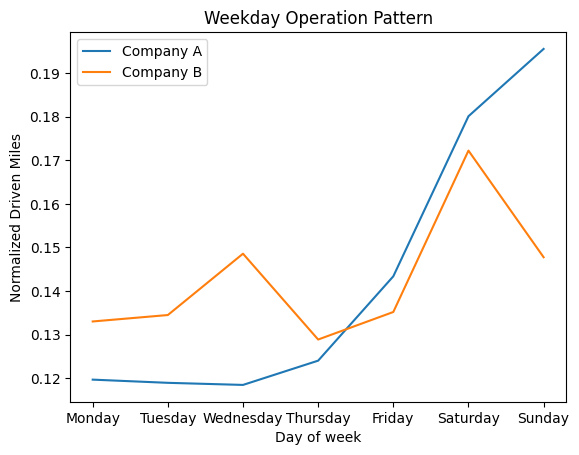

In [30]:
sum_a = df_day[df_day.company=='A'].driven_miles.sum()
sum_b = df_day[df_day.company=='B'].driven_miles.sum()

plt.plot(df_day[df_day.company=='A'].day, df_day[df_day.company=='A'].driven_miles/sum_a, label='Company A')
plt.plot(df_day[df_day.company=='B'].day, df_day[df_day.company=='B'].driven_miles/sum_b, label='Company B')
plt.legend()
plt.xlabel('Day of week')
plt.ylabel('Normalized Driven Miles')
plt.title('Weekday Operation Pattern')
plt.show()

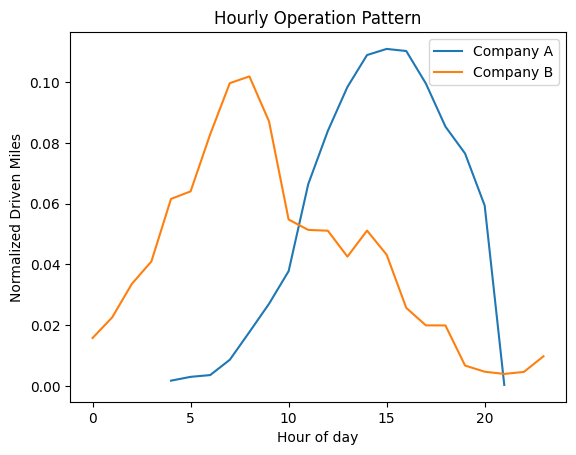

In [31]:
sum_a = df_hour[df_hour.company=='A'].driven_miles.sum()
sum_b = df_hour[df_hour.company=='B'].driven_miles.sum()

plt.plot(df_hour[df_hour.company=='A'].hour, df_hour[df_hour.company=='A'].driven_miles/sum_a, label='Company A')
plt.plot(df_hour[df_hour.company=='B'].hour, df_hour[df_hour.company=='B'].driven_miles/sum_b, label='Company B')
plt.legend()
plt.xlabel('Hour of day')
plt.ylabel('Normalized Driven Miles')
plt.title('Hourly Operation Pattern')
plt.show()

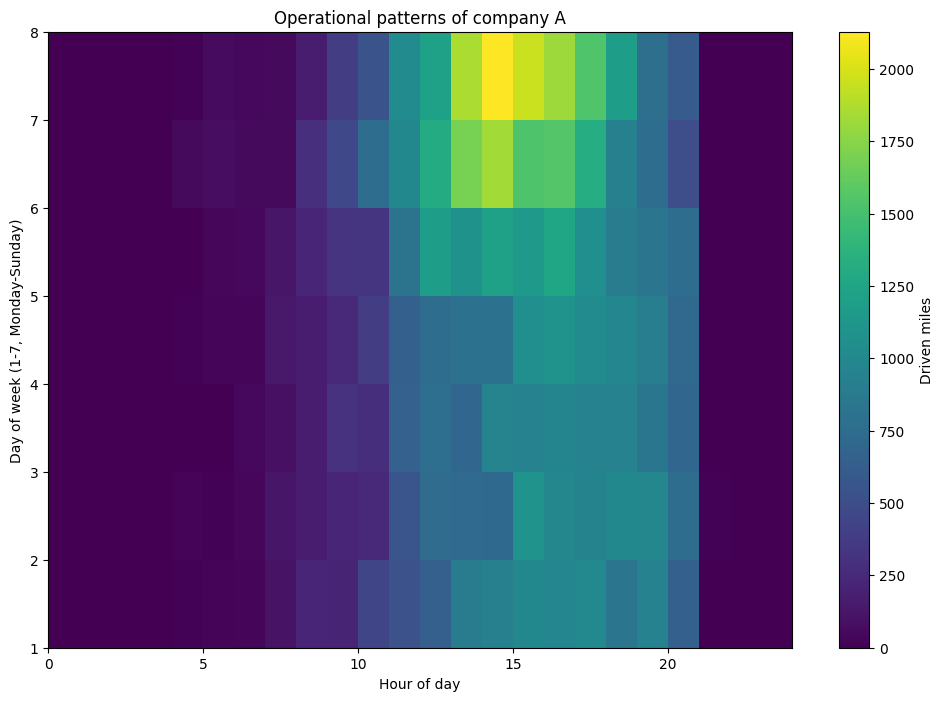

In [32]:
df_draw = df_day_hour[df_day_hour.company=='A'].copy()

# Ensure the data is numeric and clean
df_draw['hour'] = pd.to_numeric(df_draw['hour'])
df_draw['day'] = pd.factorize(df_draw['day'], sort=True)[0] + 1 
df_draw['driven_miles'] = pd.to_numeric(df_draw['driven_miles'])

# Create the 2D histogram
plt.figure(figsize=(12, 8))
h = plt.hist2d(df_draw['hour'], df_draw['day'], 
               bins=(24, 7), range=((0,24), (1,8)),  # 24 hours, 7 days
               weights=df_draw['driven_miles'],)
plt.xlabel('Hour of day')
plt.ylabel('Day of week (1-7, Monday-Sunday)')
plt.colorbar(label='Driven miles')
plt.title('Operational patterns of company A')
plt.show()




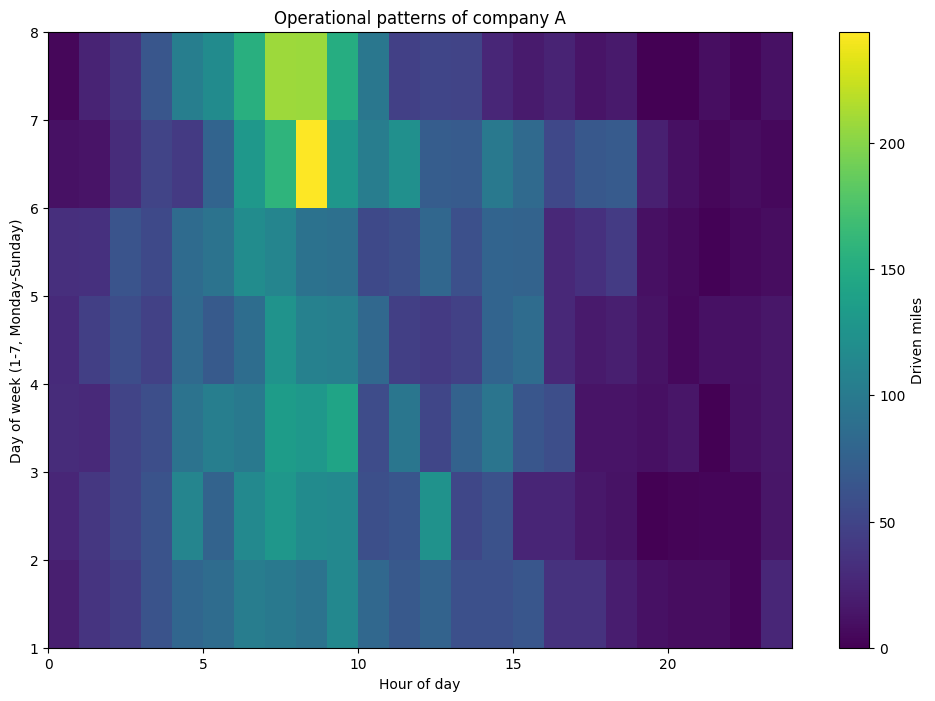

In [33]:
df_draw = df_day_hour[df_day_hour.company=='B'].copy()

# Ensure the data is numeric and clean
df_draw['hour'] = pd.to_numeric(df_draw['hour'])
df_draw['day'] = pd.factorize(df_draw['day'], sort=True)[0] + 1 
df_draw['driven_miles'] = pd.to_numeric(df_draw['driven_miles'])

# Create the 2D histogram
plt.figure(figsize=(12, 8))
h = plt.hist2d(df_draw['hour'], df_draw['day'], 
               bins=(24, 7), range=((0,24), (1,8)),  # 24 hours, 7 days
               weights=df_draw['driven_miles'],)
plt.xlabel('Hour of day')
plt.ylabel('Day of week (1-7, Monday-Sunday)')
plt.colorbar(label='Driven miles')
plt.title('Operational patterns of company A')
plt.show()

In [34]:
# per week, we need
# total driven miles
# total operation time
# total number of scooters, assuming all scooters are used at least once in a week
# total entries
df_week = df.groupby(['week','company'])[['duration_s', 'distance_m']].sum().reset_index().set_index(['week','company'])
df_num_scooter= df.groupby(['week','company'])['scooter_id'].nunique().rename('num_scooter')
df_num_ride = df.groupby(['week','company']).size().rename('num_ride')

df_week = df_week.join(df_num_scooter).join(df_num_ride)
df_week.reset_index(inplace=True)

# Change units better for weekly scale
df_week['duration_s'] = df_week['duration_s']/3600
df_week['distance_m'] = df_week['distance_m']/1609.34
df_week.rename(columns={'duration_s': 'operation_hours', 'distance_m': 'driven_miles'}, inplace=True)
df_week['miles_per_ride'] = df_week['driven_miles']/df_week['num_ride']
df_week['hours_per_ride'] = df_week['operation_hours']/df_week['num_ride']
df_week['daily_hours_per_scooter'] = df_week['operation_hours']/df_week['num_scooter']/7

df_week.sort_values(['company','week'], inplace=True)
display(df_week.head(5))
display(df_week[df_week.company=='B'].head(5))

,week,company,operation_hours,driven_miles,num_scooter,num_ride,miles_per_ride,hours_per_ride,daily_hours_per_scooter
0,2018-08-06,A,462.816667,2640.47,95,1321,1.998842,0.350353,0.695965
1,2018-08-13,A,621.016667,3615.12,89,1727,2.093295,0.359593,0.996816
2,2018-08-20,A,780.516667,4486.93,104,2369,1.894019,0.329471,1.072138
3,2018-08-27,A,825.500000,4444.45,178,2504,1.774940,0.329673,0.662520
4,2018-09-03,A,1012.266667,5545.37,161,3166,1.751538,0.319730,0.898196


,week,company,operation_hours,driven_miles,num_scooter,num_ride,miles_per_ride,hours_per_ride,daily_hours_per_scooter
17,2018-11-26,B,176.238333,662.651770,0,447,1.482442,0.394269,inf
19,2018-12-03,B,178.543056,743.934159,0,940,0.791419,0.189939,inf
21,2018-12-10,B,209.745556,964.141201,0,855,1.127651,0.245316,inf
23,2018-12-17,B,213.656389,877.046491,0,760,1.154009,0.281127,inf
25,2018-12-24,B,287.244444,1204.223470,0,862,1.397011,0.333230,inf


In [35]:
# Drop the last week data because they might not have a complete week, so underestimate the weekly aggregated values
last_week_index_list = [
    df_week[df_week.company=='A'].index.tolist()[-1],
    df_week[df_week.company=='B'].index.tolist()[-1]
]

df_week.drop(index=last_week_index_list, inplace=True)
                        

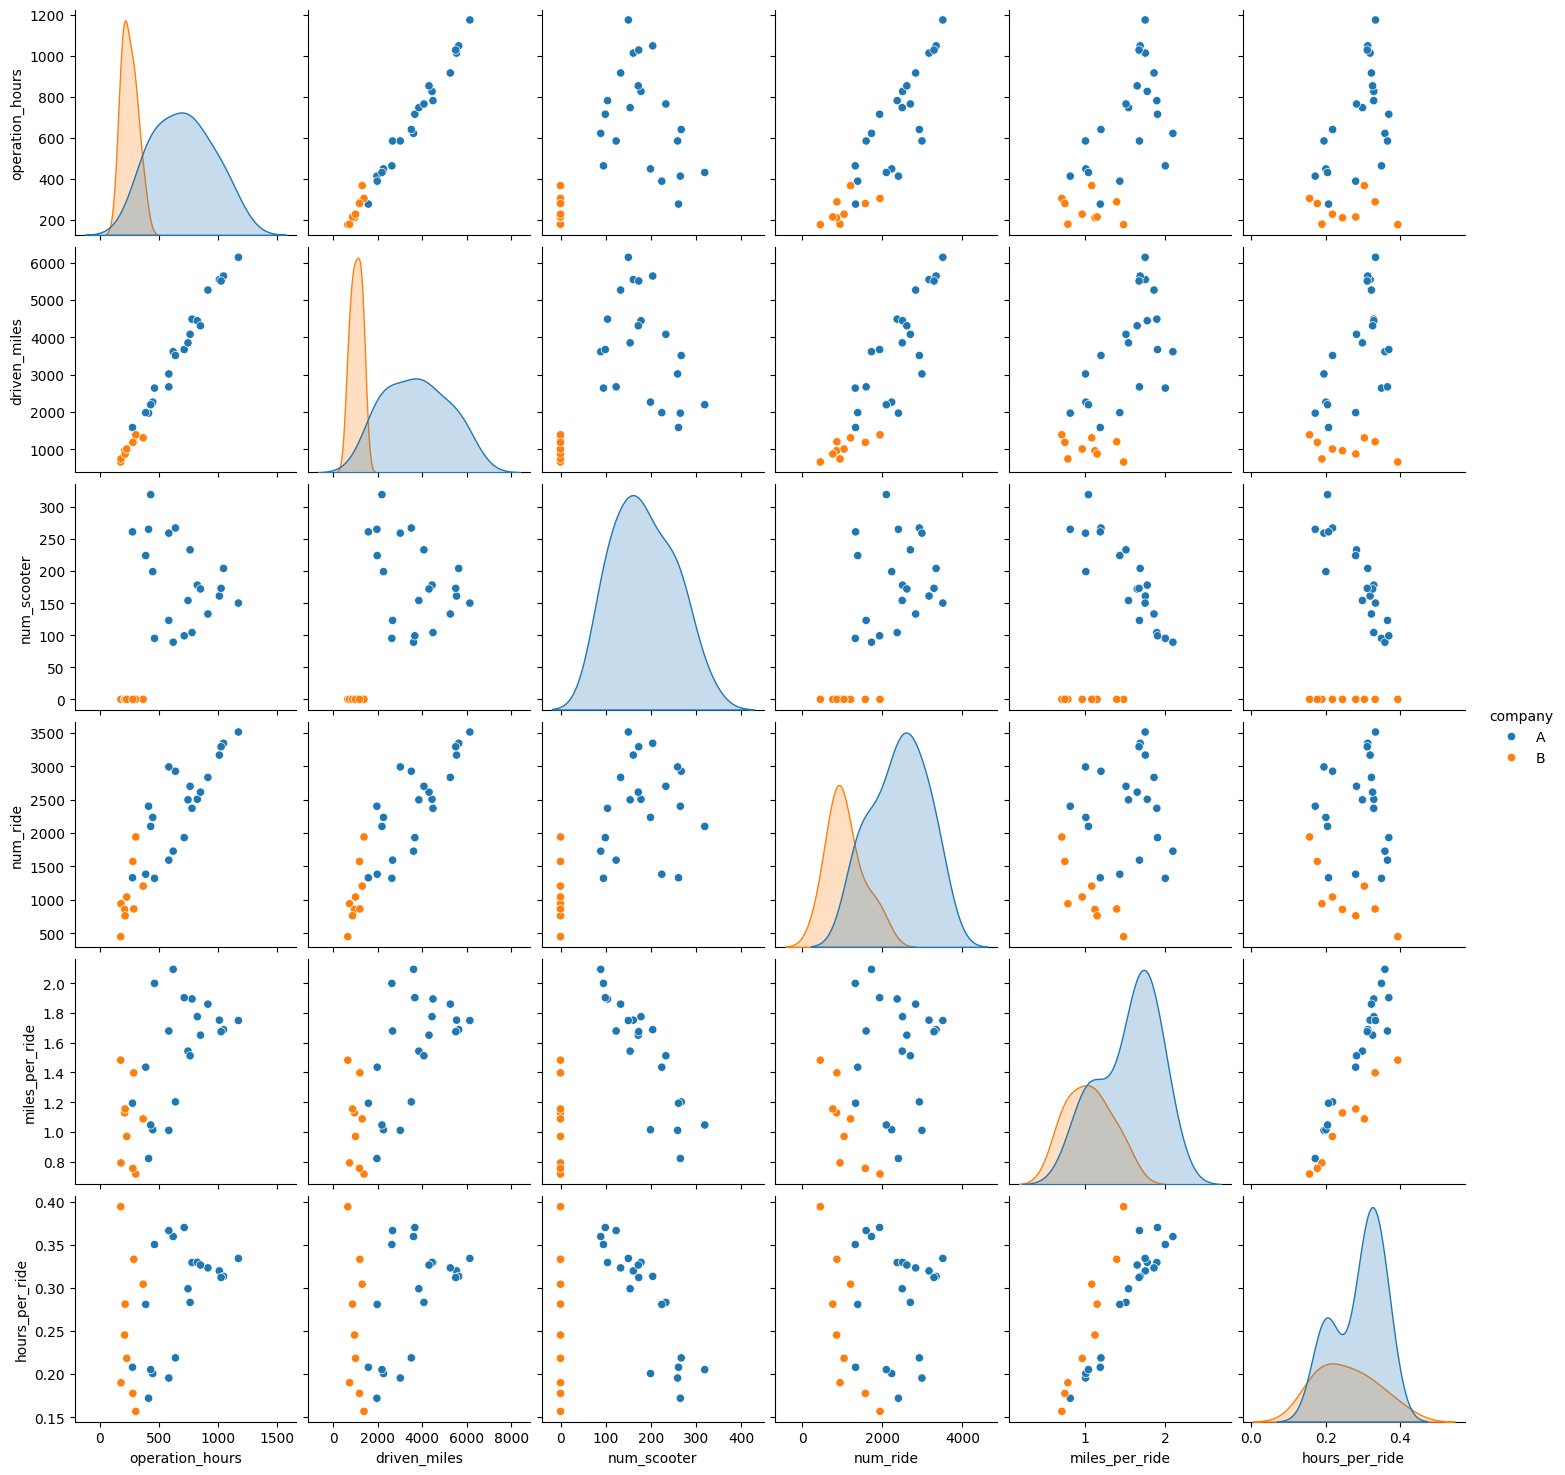

In [36]:
df_draw = df_week[['operation_hours','driven_miles','num_scooter','num_ride','company','miles_per_ride','hours_per_ride']].copy()

sns.pairplot(df_draw, hue='company')

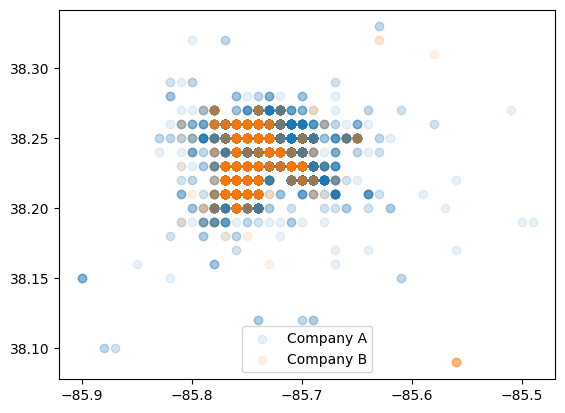

In [37]:
plt.scatter(df[df.company=='A'].start_longitude, df[df.company=='A'].start_latitude, alpha=0.1, label='Company A')
plt.scatter(df[df.company=='B'].start_longitude, df[df.company=='B'].start_latitude, alpha=0.1, label='Company B')
plt.legend()
plt.show()

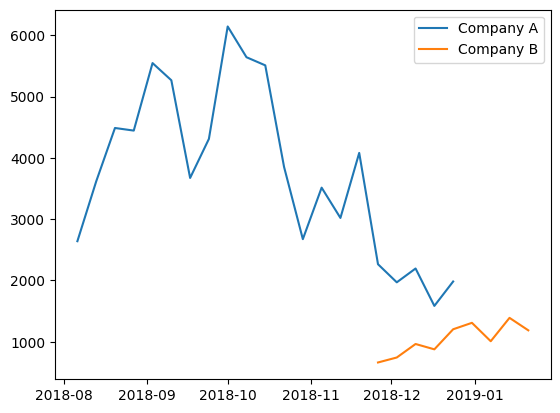

In [38]:
# Time Series
plt.plot(df_week[df_week.company=='A'].week, df_week[df_week.company=='A'].driven_miles, label='Company A')
plt.plot(df_week[df_week.company=='B'].week, df_week[df_week.company=='B'].driven_miles, label='Company B')
plt.legend()
plt.show()


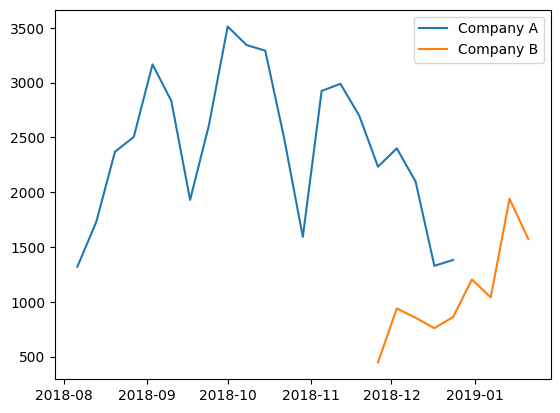

In [39]:
# Time Series
plt.plot(df_week[df_week.company=='A'].week, df_week[df_week.company=='A'].num_ride, label='Company A')
plt.plot(df_week[df_week.company=='B'].week, df_week[df_week.company=='B'].num_ride, label='Company B')
plt.legend()
plt.show()

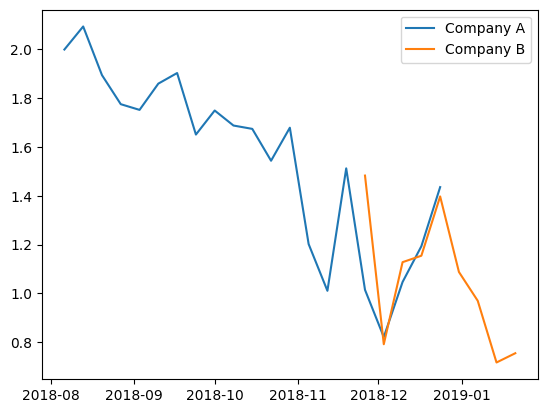

In [40]:
plt.plot(df_week[df_week.company=='A'].week, df_week[df_week.company=='A'].driven_miles/df_week[df_week.company=='A'].num_ride, label='Company A')
plt.plot(df_week[df_week.company=='B'].week, df_week[df_week.company=='B'].driven_miles/df_week[df_week.company=='B'].num_ride, label='Company B')
plt.legend()
plt.show()

# getting colder

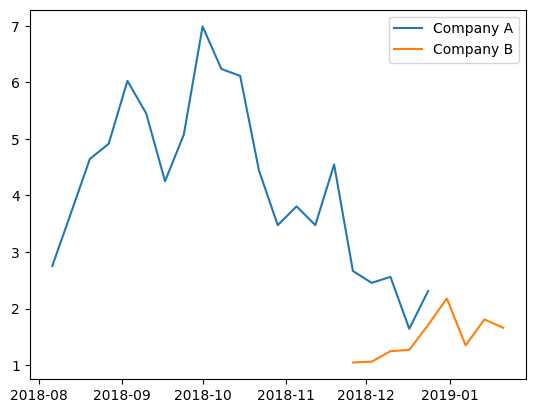

In [41]:
plt.plot(df_week[df_week.company=='A'].week, df_week[df_week.company=='A'].operation_hours/(24*7), label='Company A')
plt.plot(df_week[df_week.company=='B'].week, df_week[df_week.company=='B'].operation_hours/(24*7), label='Company B')
plt.legend()
plt.show()


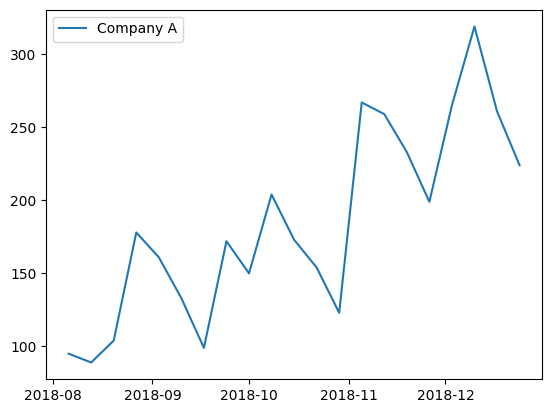

In [42]:
plt.plot(df_week[df_week.company=='A'].week, df_week[df_week.company=='A'].num_scooter, label='Company A')
plt.legend()
plt.show()

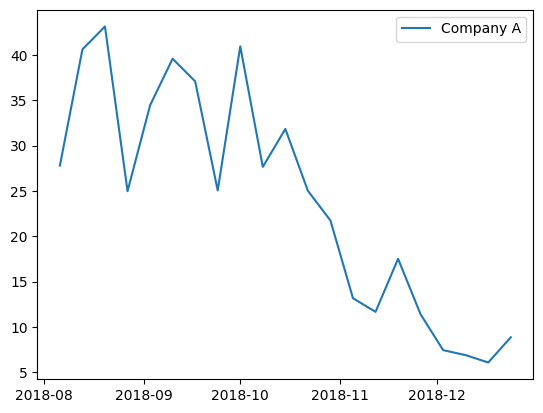

In [43]:
plt.plot(df_week[df_week.company=='A'].week, df_week[df_week.company=='A'].driven_miles/df_week[df_week.company=='A'].num_scooter, label='Company A')
plt.legend()
plt.show()

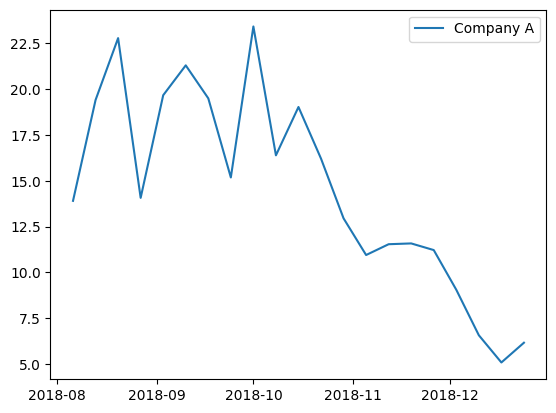

In [44]:
plt.plot(df_week[df_week.company=='A'].week, df_week[df_week.company=='A'].num_ride/df_week[df_week.company=='A'].num_scooter, label='Company A')
plt.legend()
plt.show()

In [45]:
df_est = df_week.pivot(index = 'week', columns = 'company', values = ['num_scooter', 'num_ride', 'operation_hours'])
df_est['ride_per_scooter'] = df_est['num_ride']['A']/df_est['num_scooter']['A']
df_est['hours_per_scooter'] = df_est['operation_hours']['A']/df_est['num_scooter']['A']

df_est['num_scooter_b_estimated_ride'] = df_est['num_ride']['B']/df_est['ride_per_scooter']
df_est['num_scooter_b_estimated_hours'] = df_est['operation_hours']['B']/df_est['hours_per_scooter']

# Future prediction
# Use december average
december_ride_per_scooter = df_est['ride_per_scooter'].dropna()[-4:].mean()
december_hours_per_scooter = df_est['hours_per_scooter'].dropna()[-4:].mean()

print(december_ride_per_scooter, december_hours_per_scooter)

df_est['num_scooter_b_estimated_ride_december_mean'] = df_est['num_ride']['B']/december_ride_per_scooter
df_est['num_scooter_b_estimated_hours_december_mean'] = df_est['operation_hours']['B']/december_hours_per_scooter

df_draw = df_est[[
    'num_scooter_b_estimated_ride',
    'num_scooter_b_estimated_hours',
    'num_scooter_b_estimated_ride_december_mean',
    'num_scooter_b_estimated_hours_december_mean'
]].reset_index()


6.723750790388315 1.4242993645227096


In [46]:
scooter_id_list_university = df[(df.start_latitude==38.22)].scooter_id.unique()


In [47]:
scooter_id_list = df.scooter_id.unique()
tp = df[(df.scooter_id==scooter_id_list_university[4])|(df.scooter_id==scooter_id_list[4])]

import plotly.express as px

fig = px.density_heatmap(
    tp, x="start_longitude", y="start_latitude", 
    facet_col="scooter_id",
    range_x=[-85.81, -85.66], range_y=[38.15, 38.30],
    title="Pick-up locations"
    )
fig.show()


count      3918.000000
mean      13537.335375
std       12885.294963
min          60.000000
25%        4215.000000
50%        9780.000000
75%       19545.000000
max      207000.000000
Name: duration_s, dtype: float64

<Axes: xlabel='week', ylabel='duration_s'>

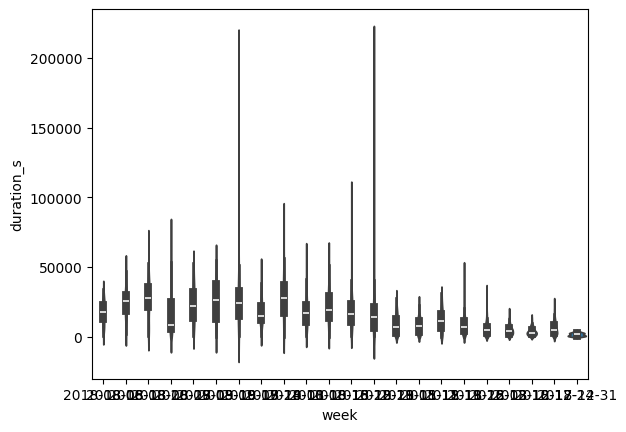

In [48]:
# Operational Patterns
df_agg = df.groupby(['week','scooter_id'])[['duration_s', 'distance_m']].sum().reset_index()

display(df_agg.duration_s.describe())

sns.violinplot(data=df_agg, x="week", y="duration_s")


In [49]:
len(df_day)

14

(array([17860., 17864., 17866., 17870., 17874., 17878., 17882., 17886.,
        17890.]),
 [Text(17860.0, 0, '2018-11-25'),
  Text(17864.0, 0, '2018-11-29'),
  Text(17866.0, 0, '2018-12-01'),
  Text(17870.0, 0, '2018-12-05'),
  Text(17874.0, 0, '2018-12-09'),
  Text(17878.0, 0, '2018-12-13'),
  Text(17882.0, 0, '2018-12-17'),
  Text(17886.0, 0, '2018-12-21'),
  Text(17890.0, 0, '2018-12-25')])

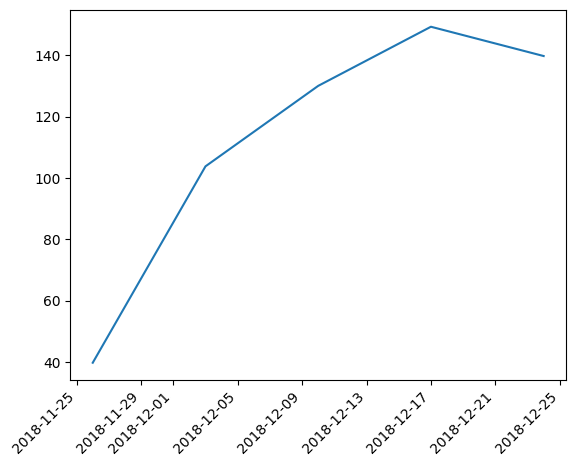

In [50]:
# Draw estimation - ride per scooter

import matplotlib.ticker as ticker

x = pd.date_range('2018-11-03', '2019-03-20')

plt.plot(df_draw['week'], df_est['num_scooter_b_estimated_ride'])

plt.xticks(rotation=45, ha='right')

Daily fluctuations are too large to see trend. Let's aggregate.

### Findings
- Company A's total driven has increased during Aug-Oct in 2018, then decreased during Nov and Dec.
- Company B's total driven has grown from Dec 2018 to Jan 2019.

### Further suggestions
- It seems there are overlapping period in Decempber. By using the estimated number of scooters of company B, we can also compare which company is more effectively operating by comparing [Discance]/[Number of scooters]